## Name :- Gaurav Bhore
## Roll No :- 7
## Batch :- 1
## ML Lab Exp 8

In [2]:
!pip install requests

In [4]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans,AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

## Part 1 :- Setting up the data with World Bank API

In [7]:
def fetch_indicator(code,year="2022"):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{code}?date={year}&format=json&per_page=30000"
    response = requests.get(url).json()[1]
    data = {}
    for item in response:
        country = item["country"]["value"]
        value = item["value"]
        if value is not None:
            data[country] = value
    return pd.Series(data,name=code)

In [12]:
gdp = fetch_indicator("NY.GDP.PCAP.CD")
pop = fetch_indicator("SP.POP.TOTL")
life = fetch_indicator("SP.DYN.LE00.IN")
lit = fetch_indicator("SE.ADT.LITR.ZS")

In [32]:
df = pd.concat([gdp,pop,life,lit],axis=1)
df.columns = ["GDP","Population","LifeExpectancy","Literacy"]
df.dropna(inplace=True)
df.head()

,GDP,Population,LifeExpectancy,Literacy
Africa Eastern and Southern,1679.327622,731821393,64.487020,73.055977
Africa Western and Central,2138.473153,497387180,57.987813,60.780979
Arab World,7950.355820,471352066,71.876096,78.271927
Central Europe and the Baltics,19530.155323,100071871,76.652299,99.479919
Early-demographic dividend,4043.827763,3470644834,71.430455,81.242798


In [33]:
df.tail()

,GDP,Population,LifeExpectancy,Literacy
Uruguay,20818.614609,3390913,76.468,98.849998
Uzbekistan,2578.666894,34938955,72.147,100.000000
Viet Nam,4147.697772,99680655,74.502,96.129997
West Bank and Gaza,3799.955270,5043612,76.662,97.839996
Zambia,1447.123101,20152938,65.279,79.975143


In [34]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

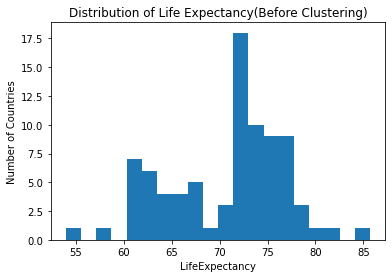

In [35]:
plt.figure(figsize=(6,4))
plt.hist(df["LifeExpectancy"],bins=20)
plt.xlabel("LifeExpectancy")
plt.ylabel("Number of Countries")
plt.title("Distribution of Life Expectancy(Before Clustering)")
plt.show()

## Part 2 :- Elbow Method

C:\Users\HP\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1036: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


k	wcss
1 	 335.99999999999994
2 	 206.43717192603816
3 	 140.44737992159946
4 	 84.95472291479635
5 	 65.28700678578714
6 	 53.63698303866686
7 	 44.68836879056017
8 	 35.89925019293267
9 	 30.437041739777428
10 	 26.57948803011636


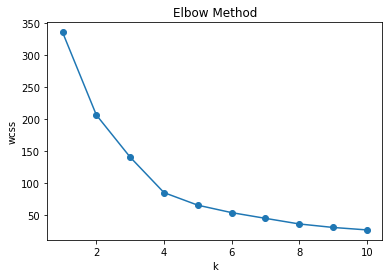

In [36]:
wcss = []

for k in range(1,11):
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(x_scaled)
    wcss.append(km.inertia_)
    
print("k\twcss")
for i in range(10):
    print(i+1, "\t", wcss[i])
    
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("k")
plt.ylabel("wcss")
plt.title("Elbow Method")
plt.show()

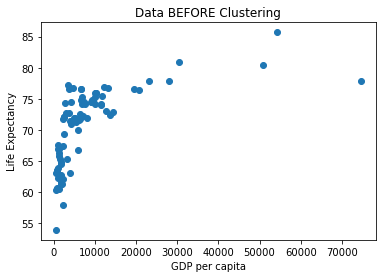

In [37]:
plt.scatter(df["GDP"], df["LifeExpectancy"])

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data BEFORE Clustering")

plt.show()

In [38]:
kmeans =KMeans(n_clusters=3, random_state=0)
labels_km = kmeans.fit_predict(x_scaled)
df["KMeansCluster"] = labels_km

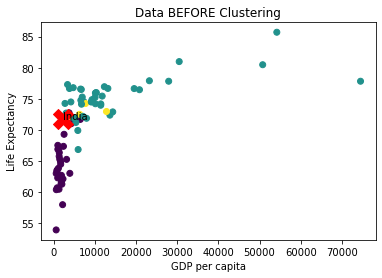

In [46]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_km)

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Data BEFORE Clustering")

india = df.loc["India"]
plt.scatter(india["GDP"], india["LifeExpectancy"], s=400, color='Red', marker='X')
plt.text(india["GDP"], india["LifeExpectancy"], "India")

plt.show()

In [40]:
hc = AgglomerativeClustering(n_clusters=3)
labels_hc = hc.fit_predict(x_scaled)
df["HierarchicalCluster"] = labels_hc

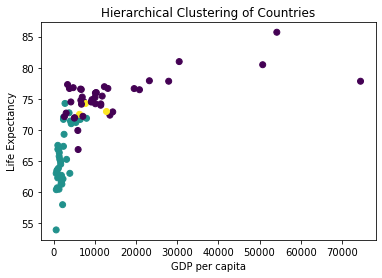

In [41]:
plt.scatter(df["GDP"], df["LifeExpectancy"], c=labels_hc)

plt.xlabel("GDP per capita")
plt.ylabel("Life Expectancy")
plt.title("Hierarchical Clustering of Countries")

plt.show()

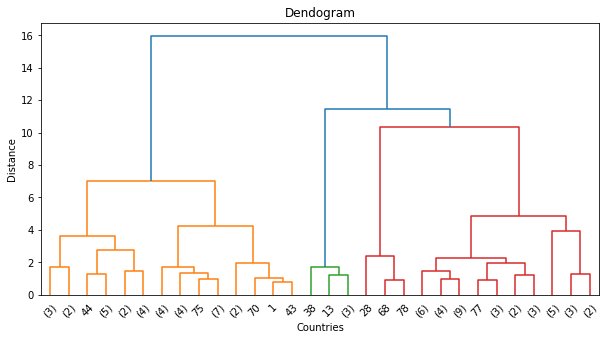

In [42]:
linked = linkage(x_scaled, method="ward")

plt.figure(figsize=(10,5))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Dendogram")
plt.xlabel("Countries")
plt.ylabel("Distance")
plt.show()

In [45]:
country_name = "India"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: India
GDP per capita: 2347.44829434623
Population: 1425423212.0
Life Expectancy: 71.698
Literacy Rate: 76.3199996948242
KMeans Cluster: 0.0
Hierarchical Cluster: 1.0


In [49]:
country_name = "North America"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: North America
GDP per capita: 74535.6365392629
Population: 373018004.0
Life Expectancy: 77.8327679594239
Literacy Rate: 98.7891464233398
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [50]:
country_name = "Brazil"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Brazil
GDP per capita: 9281.33282136864
Population: 210306415.0
Life Expectancy: 74.872
Literacy Rate: 94.3853874531348
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [51]:
country_name = "Viet Nam"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Viet Nam
GDP per capita: 4147.69777213621
Population: 99680655.0
Life Expectancy: 74.502
Literacy Rate: 96.129997253418
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [52]:
country_name = "Bahrain"
result = df.loc[country_name]
print("Country:", country_name)
print("GDP per capita:", result["GDP"])
print("Population:", result["Population"])
print("Life Expectancy:", result["LifeExpectancy"])
print("Literacy Rate:", result["Literacy"])
print("KMeans Cluster:", result["KMeansCluster"])
print("Hierarchical Cluster:", result["HierarchicalCluster"])

Country: Bahrain
GDP per capita: 30470.5219276023
Population: 1524693.0
Life Expectancy: 80.992
Literacy Rate: 97.870002746582
KMeans Cluster: 1.0
Hierarchical Cluster: 0.0


In [48]:
cluster_summary = df.groupby("KMeansCluster")[["GDP", "Population", "LifeExpectancy", "Literacy"]].mean()
print(cluster_summary)

                        GDP    Population  LifeExpectancy   Literacy
KMeansCluster                                                       
0               1915.596661  6.544831e+08       64.856833  68.564031
1              13280.490845  3.923248e+08       75.101970  94.739797
2               7094.638897  5.911254e+09       72.421619  86.116721
